In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.data.load_data import load_and_prepare_data, create_preprocessing_pipeline

In [5]:
# Загрузка данных
df = load_and_prepare_data()
print(f"Размер данных: {df.shape}")
df.head()

Размер данных: (1000, 9)


,age,income,loan_amount,loan_duration,employment_years,credit_history,purpose,savings,default
0,56,125186,19546,13,30,fair,education,41785,0
1,69,54674,20129,30,25,poor,business,36547,1
2,46,55854,2591,71,4,poor,car,42818,1
3,32,66271,12303,55,19,good,car,34886,0
4,60,93688,31561,54,10,poor,home,6391,0


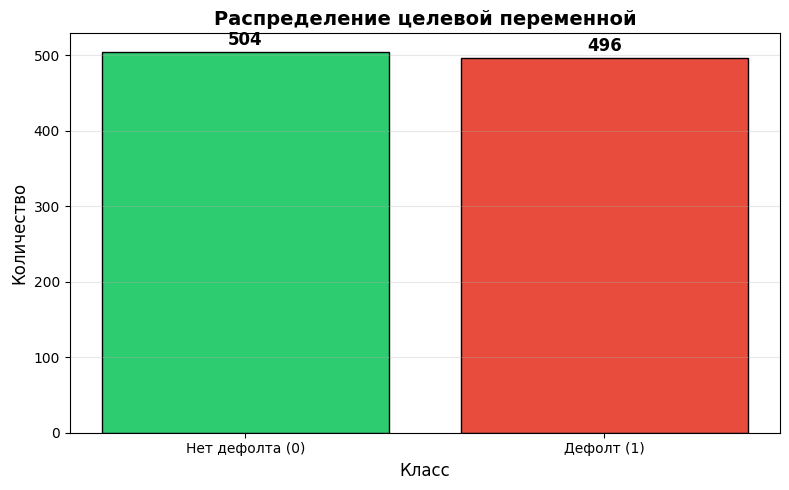

Процент дефолтов: 49.60%


In [6]:
# Распределение целевой переменной (Рисунок 1.1)
plt.figure(figsize=(8, 5))
counts = df['default'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.bar(['Нет дефолта (0)', 'Дефолт (1)'], counts.values, color=colors, edgecolor='black')
plt.title('Распределение целевой переменной', fontsize=14, fontweight='bold')
plt.ylabel('Количество', fontsize=12)
plt.xlabel('Класс', fontsize=12)
for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figure1_1_default_distribution.png', dpi=150)
plt.show()

print(f"Процент дефолтов: {df['default'].mean()*100:.2f}%")

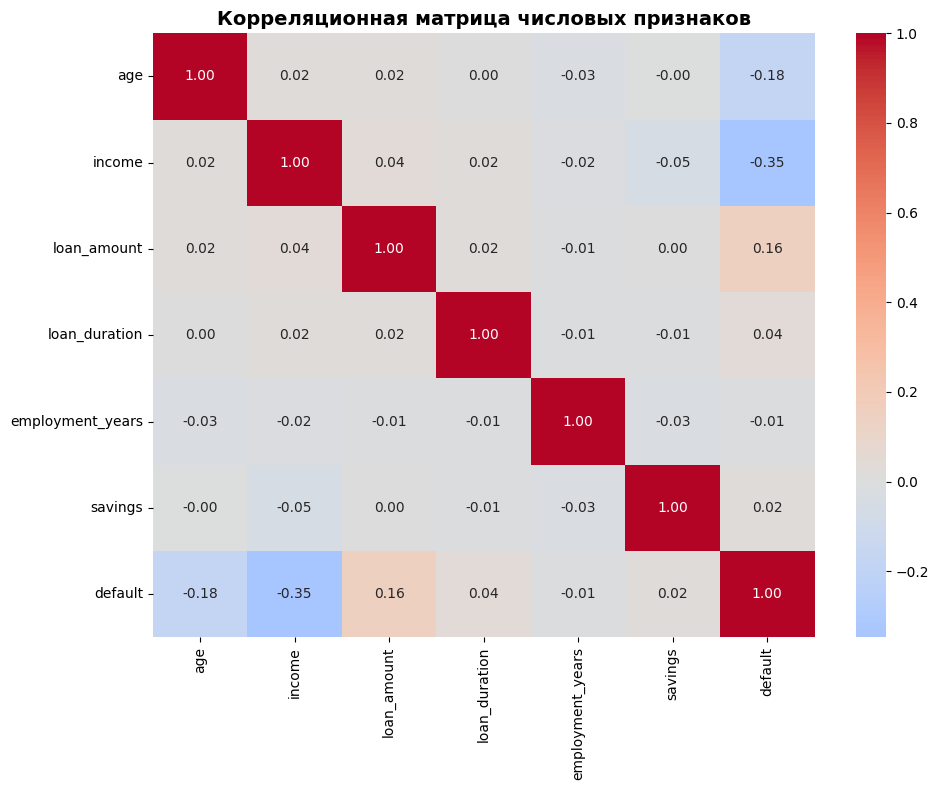

In [7]:
# Корреляционная матрица
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляционная матрица числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figure_correlation_matrix.png', dpi=150)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Подготовка данных
X = df.drop('default', axis=1)
y = df['default']

preprocessor = create_preprocessing_pipeline()
X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42)

# Обучение моделей
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
print("Результаты экспериментов:")
print(results_df.to_string(index=False))

Результаты экспериментов:
              Model  Accuracy  ROC-AUC
Logistic Regression  0.800000 0.897589
      Random Forest  0.906667 0.958036
            XGBoost  0.903333 0.967232


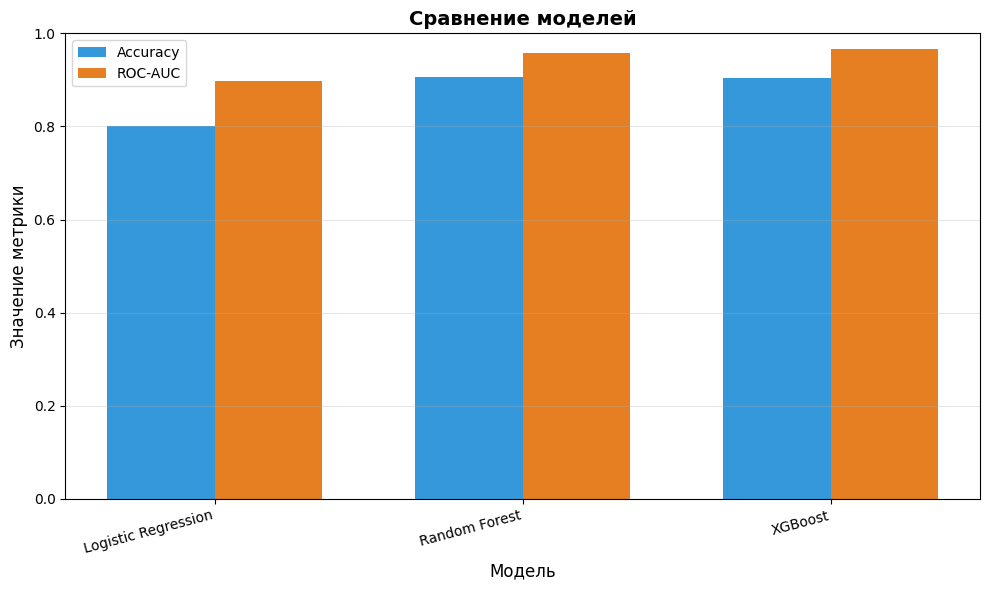


✅ Рисунок 1.1 сохранён: figure1_1_default_distribution.png
✅ Корреляционная матрица: figure_correlation_matrix.png
✅ Сравнение моделей: figure_models_comparison.png


In [9]:
# Сравнение моделей
plt.figure(figsize=(10, 6))
x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='#3498db')
plt.bar(x + width/2, results_df['ROC-AUC'], width, label='ROC-AUC', color='#e67e22')

plt.xlabel('Модель', fontsize=12)
plt.ylabel('Значение метрики', fontsize=12)
plt.title('Сравнение моделей', fontsize=14, fontweight='bold')
plt.xticks(x, results_df['Model'], rotation=15, ha='right')
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figure_models_comparison.png', dpi=150)
plt.show()

print("\n✅ Рисунок 1.1 сохранён: figure1_1_default_distribution.png")
print("✅ Корреляционная матрица: figure_correlation_matrix.png")
print("✅ Сравнение моделей: figure_models_comparison.png")